# League Analysis

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

model_aliases = {
    "fixed_2p": "DQN Fixed",
    "fixed_3p": "DQN Fixed",
    "fixed_4p": "DQN Fixed",
    "variable_2_4": "DQN Variable",
    "variable_encoder_2_4": "DQN Variable + Encoder",
    "random": "Random",
}
model_order = ["DQN Fixed", "DQN Variable", "DQN Variable + Encoder", "Random"]

result_roots = [Path("results/league_results"), Path("../../results/league_results")]
results_root = next(path for path in result_roots if path.exists())

frames = []
for player_count in (2, 3, 4):
    path = results_root / f"{player_count}p" / "matches.csv"
    if not path.exists():
        continue
    data = pd.read_csv(path)
    data["player_count"] = player_count
    frames.append(data)

df = pd.concat(frames, ignore_index=True)
def split_pipe(value):
    return str(value).split("|")

def mean_pipe_ints(value):
    values = [int(part) for part in split_pipe(value)]
    return sum(values) / len(values)

df["competitor_label"] = df["competitor"].map(model_aliases)
df["opponent_labels"] = df["opponent_competitors"].apply(
    lambda names: [model_aliases[name] for name in split_pipe(names)]
)
df["opponent_mean_points"] = df["opponent_points_all"].apply(mean_pipe_ints)
df["point_margin"] = df["points"] - df["opponent_mean_points"]
df["won"] = df["outcome"].eq("win")
df["player_count_label"] = df["player_count"].astype(str) + "p"

## Results Loaded

In [2]:
loaded = (
    df.groupby("player_count")
      .agg(rows=("match_id", "size"), games=("match_id", "nunique"), matchups=("matchup_id", "nunique"))
      .reset_index()
)
loaded

,player_count,rows,games,matchups
0,2,9000,4500,45
1,3,35100,11700,117
2,4,84000,21000,210


## Overall Results

In [3]:
overall = (
    df.groupby(["player_count", "competitor_label"])
      .agg(
          games=("match_id", "size"),
          wins=("won", "sum"),
          losses=("outcome", lambda x: x.eq("loss").sum()),
          ties=("outcome", lambda x: x.eq("tie").sum()),
          raw_win_rate=("won", "mean"),
          mean_points=("points", "mean"),
          mean_margin=("point_margin", "mean"),
      )
      .reset_index()
)
overall.style.format({
    "raw_win_rate": "{:.1%}",
    "mean_points": "{:.2f}",
    "mean_margin": "{:+.2f}",
})

,player_count,competitor_label,games,wins,losses,ties,raw_win_rate,mean_points,mean_margin
0,2,DQN Fixed,2700,1378,1288,34,51.0%,56.69,+2.07
1,2,DQN Variable,2700,1299,1374,27,48.1%,56.36,+1.51
2,2,DQN Variable + Encoder,2700,1775,896,29,65.7%,58.15,+5.11
3,2,Random,900,3,897,0,0.3%,39.13,-26.08
4,3,DQN Fixed,10500,3632,6705,163,34.6%,47.06,+2.54
5,3,DQN Variable,10500,3813,6559,128,36.3%,46.99,+2.51
6,3,DQN Variable + Encoder,10500,4058,6341,101,38.6%,47.67,+3.28
7,3,Random,3600,1,3598,1,0.0%,26.69,-24.30
8,4,DQN Fixed,25200,7231,17679,290,28.7%,39.92,+2.60
9,4,DQN Variable,25200,6225,18708,267,24.7%,39.29,+1.75


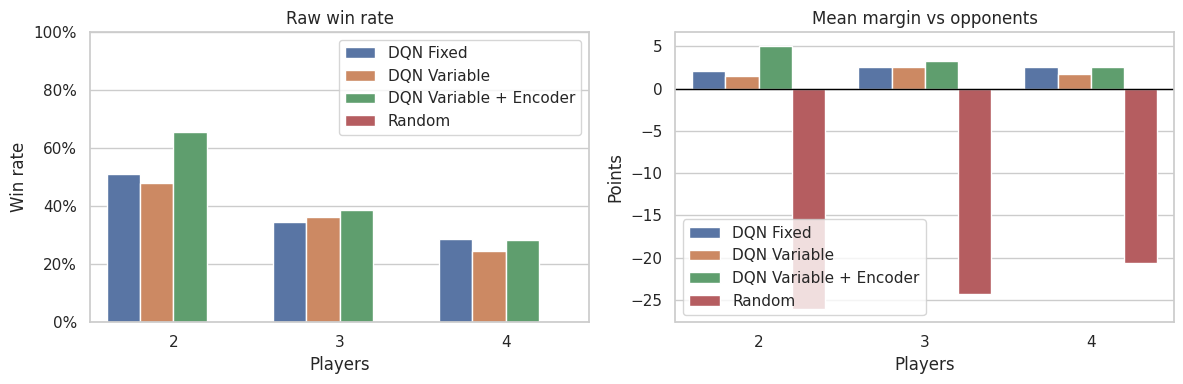

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=overall,
    x="player_count",
    y="raw_win_rate",
    hue="competitor_label",
    hue_order=model_order,
    errorbar=None,
    ax=axes[0],
)
axes[0].set_title("Raw win rate")
axes[0].set_xlabel("Players")
axes[0].set_ylabel("Win rate")
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

sns.barplot(
    data=overall,
    x="player_count",
    y="mean_margin",
    hue="competitor_label",
    hue_order=model_order,
    errorbar=None,
    ax=axes[1],
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Mean margin vs opponents")
axes[1].set_xlabel("Players")
axes[1].set_ylabel("Points")

for ax in axes:
    ax.legend(title="")
plt.tight_layout()

## Matchup View

In [5]:
opponent_rows = []
for row in df.itertuples(index=False):
    for opponent_label in row.opponent_labels:
        opponent_rows.append({
            "player_count": row.player_count,
            "competitor_label": row.competitor_label,
            "opponent_label": opponent_label,
            "won": row.won,
            "point_margin": row.point_margin,
        })

opponent_df = pd.DataFrame(opponent_rows)
matchup_summary = (
    opponent_df.groupby(["player_count", "competitor_label", "opponent_label"])
      .agg(
          rows=("won", "size"),
          raw_win_rate=("won", "mean"),
          mean_margin=("point_margin", "mean"),
      )
      .reset_index()
)
matchup_summary.style.format({
    "raw_win_rate": "{:.1%}",
    "mean_margin": "{:+.2f}",
})

,player_count,competitor_label,opponent_label,rows,raw_win_rate,mean_margin
0,2,DQN Fixed,DQN Fixed,600,49.0%,+0.00
1,2,DQN Fixed,DQN Variable,900,52.6%,+0.62
2,2,DQN Fixed,DQN Variable + Encoder,900,34.6%,-2.92
3,2,DQN Fixed,Random,300,100.0%,+25.57
4,2,DQN Variable,DQN Fixed,900,45.8%,-0.62
5,2,DQN Variable,DQN Variable,600,49.5%,+0.00
6,2,DQN Variable,DQN Variable + Encoder,900,32.6%,-3.21
7,2,DQN Variable,Random,300,99.0%,+25.12
8,2,DQN Variable + Encoder,DQN Fixed,900,64.7%,+2.92
9,2,DQN Variable + Encoder,DQN Variable,900,66.8%,+3.21


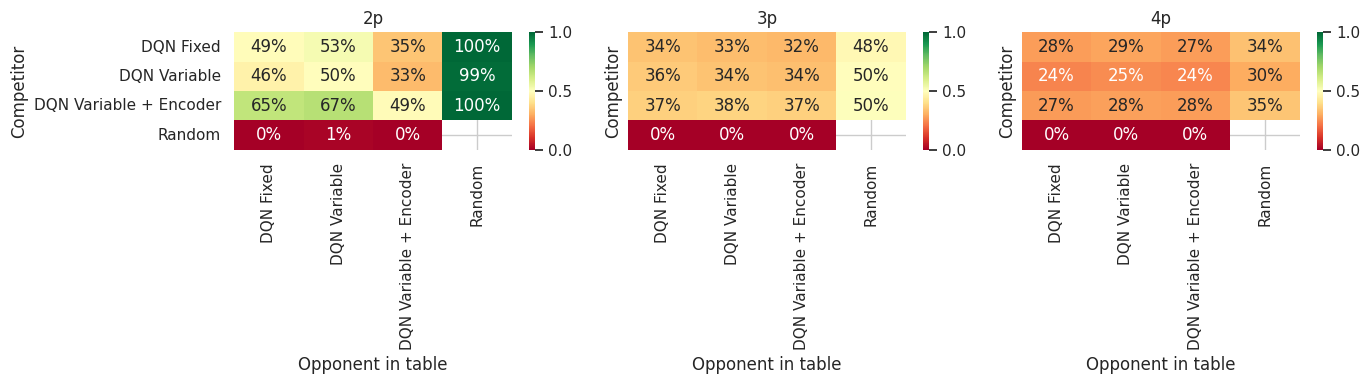

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, player_count in zip(axes, (2, 3, 4)):
    matrix = matchup_summary[matchup_summary["player_count"] == player_count].pivot(
        index="competitor_label", columns="opponent_label", values="raw_win_rate"
    ).reindex(index=model_order, columns=model_order)
    sns.heatmap(matrix, annot=True, fmt=".0%", vmin=0, vmax=1, cmap="RdYlGn", ax=ax)
    ax.set_title(f"{player_count}p")
    ax.set_xlabel("Opponent in table")
    ax.set_ylabel("Competitor")
plt.tight_layout()

## Repetition Variance

In [7]:
repetition_win_rates = (
    df.groupby(["player_count", "competitor_label", "repetition"])
      .agg(games=("match_id", "size"), raw_win_rate=("won", "mean"))
      .reset_index()
)

win_rate_variance = (
    repetition_win_rates.groupby(["player_count", "competitor_label"])
      .agg(
          repetitions=("repetition", "nunique"),
          mean_win_rate=("raw_win_rate", "mean"),
          win_rate_variance=("raw_win_rate", "var"),
      )
      .reset_index()
)
win_rate_variance["win_rate_variance"] = win_rate_variance["win_rate_variance"].fillna(0)
win_rate_variance.style.format({
    "mean_win_rate": "{:.1%}",
    "win_rate_variance": "{:.4f}",
})

,player_count,competitor_label,repetitions,mean_win_rate,win_rate_variance
0,2,DQN Fixed,3,51.0%,0.0010
1,2,DQN Variable,3,48.1%,0.0025
2,2,DQN Variable + Encoder,3,65.7%,0.0025
3,2,Random,1,0.3%,0.0000
4,3,DQN Fixed,3,34.6%,0.0001
5,3,DQN Variable,3,36.3%,0.0005
6,3,DQN Variable + Encoder,3,38.6%,0.0002
7,3,Random,1,0.0%,0.0000
8,4,DQN Fixed,3,28.7%,0.0002
9,4,DQN Variable,3,24.7%,0.0002


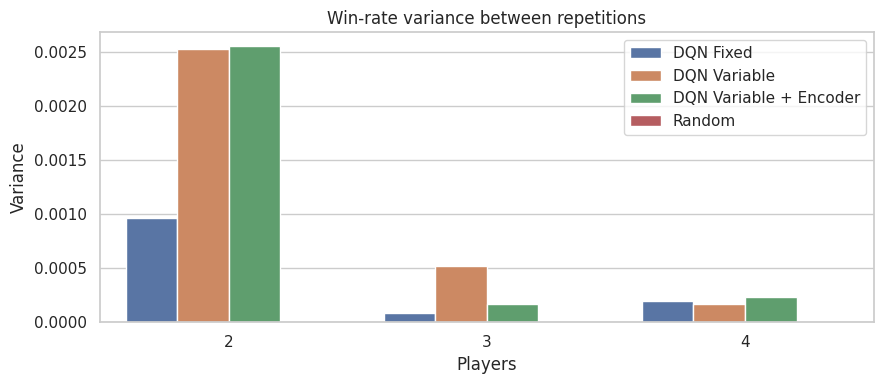

In [8]:
plt.figure(figsize=(9, 4))
sns.barplot(
    data=win_rate_variance,
    x="player_count",
    y="win_rate_variance",
    hue="competitor_label",
    hue_order=model_order,
    errorbar=None,
)
plt.title("Win-rate variance between repetitions")
plt.xlabel("Players")
plt.ylabel("Variance")
plt.legend(title="")
plt.tight_layout()

## Seat Effects

In [9]:
seat_results = (
    df.groupby(["player_count", "competitor_label", "seat"])
      .agg(
          games=("match_id", "size"),
          raw_win_rate=("won", "mean"),
          mean_margin=("point_margin", "mean"),
      )
      .reset_index()
)
seat_results.style.format({
    "raw_win_rate": "{:.1%}",
    "mean_margin": "{:+.2f}",
})

,player_count,competitor_label,seat,games,raw_win_rate,mean_margin
0,2,DQN Fixed,0,1298,52.4%,+2.18
1,2,DQN Fixed,1,1402,49.8%,+1.97
2,2,DQN Variable,0,1350,48.7%,+1.81
3,2,DQN Variable,1,1350,47.5%,+1.22
4,2,DQN Variable + Encoder,0,1380,66.9%,+5.00
5,2,DQN Variable + Encoder,1,1320,64.5%,+5.22
6,2,Random,0,472,0.2%,-26.47
7,2,Random,1,428,0.5%,-25.65
8,3,DQN Fixed,0,3533,34.2%,+2.70
9,3,DQN Fixed,1,3493,35.8%,+2.43


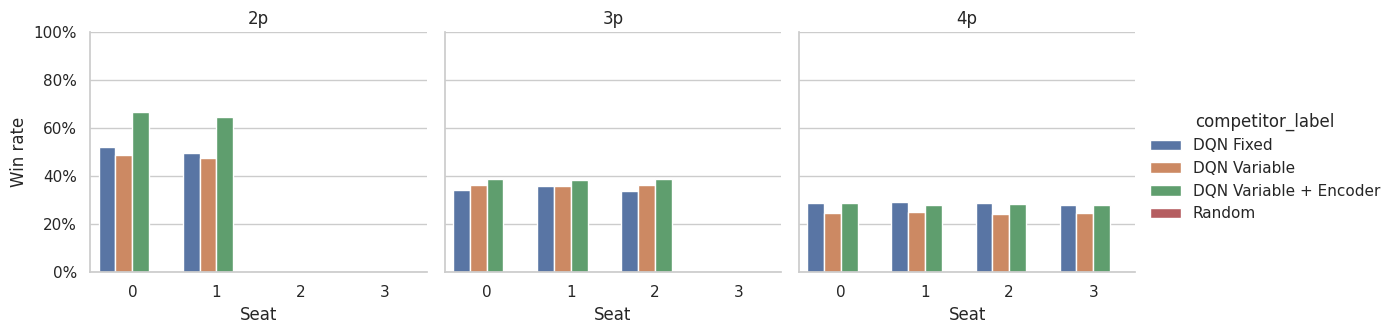

In [10]:
grid = sns.catplot(
    data=seat_results,
    kind="bar",
    x="seat",
    y="raw_win_rate",
    hue="competitor_label",
    hue_order=model_order,
    col="player_count",
    errorbar=None,
    height=3.5,
    aspect=1.1,
)
grid.set_axis_labels("Seat", "Win rate")
grid.set_titles("{col_name}p")
for ax in grid.axes.flat:
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

## Training Metrics

In [11]:
metrics_candidates = [Path("results/league"), Path("../../results/league")]
metrics_root = next(path for path in metrics_candidates if path.exists())

checkpoint_aliases = {
    "fixed_2p": "DQN Fixed 2 Players",
    "fixed_3p": "DQN Fixed 3 Players",
    "fixed_4p": "DQN Fixed 4 Players",
    "variable_2_4": "DQN Variable",
    "variable_encoder_2_4": "DQN Variable + Encoder",
}

training_metrics = []
for model, alias in checkpoint_aliases.items():
    for metrics_path in sorted((metrics_root / model).glob("repetition_*/metrics.csv")):
        metrics = pd.read_csv(metrics_path)
        metrics["checkpoint"] = alias
        metrics["repetition"] = int(metrics_path.parent.name.removeprefix("repetition_"))
        training_metrics.append(metrics)

training_df = pd.concat(training_metrics, ignore_index=True)
training_df["loss_smoothed"] = training_df.groupby(["checkpoint", "repetition"])["loss"].transform(
    lambda x: x.rolling(100, min_periods=1).mean()
)
training_df["return_smoothed"] = training_df.groupby(["checkpoint", "repetition"])["mean_episode_return"].transform(
    lambda x: x.rolling(100, min_periods=1).mean()
)

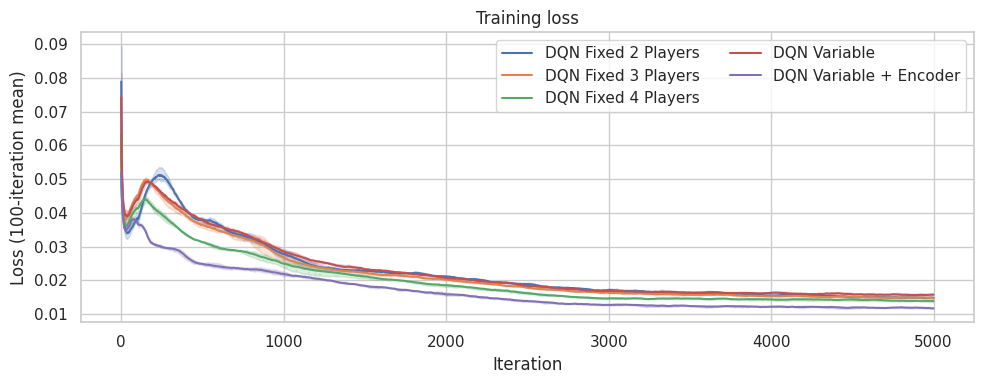

In [12]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=training_df, x="iteration", y="loss_smoothed", hue="checkpoint")
plt.title("Training loss")
plt.xlabel("Iteration")
plt.ylabel("Loss (100-iteration mean)")
plt.legend(title="", ncol=2)
plt.tight_layout()

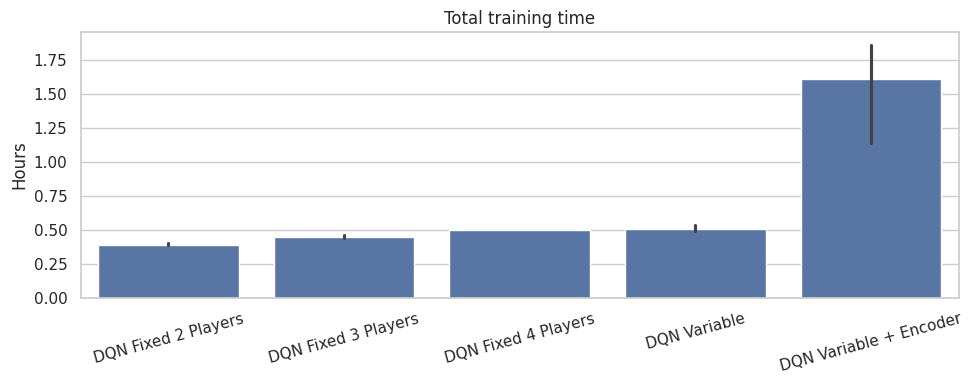

In [13]:
training_time = training_df.groupby(["checkpoint", "repetition"], as_index=False)["elapsed_seconds"].max()
training_time["hours"] = training_time["elapsed_seconds"] / 3600

plt.figure(figsize=(10, 4))
sns.barplot(data=training_time, x="checkpoint", y="hours")
plt.title("Total training time")
plt.xlabel("")
plt.ylabel("Hours")
plt.xticks(rotation=15)
plt.tight_layout()

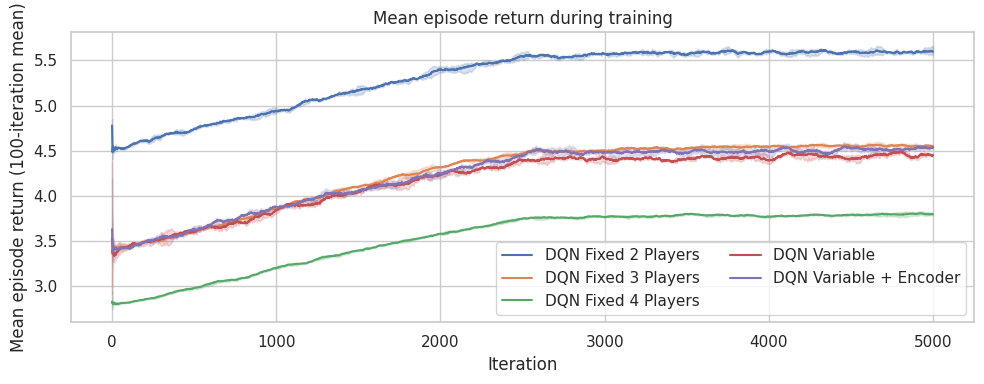

In [14]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=training_df, x="iteration", y="return_smoothed", hue="checkpoint")
plt.title("Mean episode return during training")
plt.xlabel("Iteration")
plt.ylabel("Mean episode return (100-iteration mean)")
plt.legend(title="", ncol=2)
plt.tight_layout()